# EDA de PaySim: detección de fraude en transacciones móviles

**Objetivo.** Entender cómo se comporta el fraude en PaySim (dataset sintético) y decidir qué variables son *legítimas* para un modelo que se desplegará como endpoint de predicción en tiempo real en Azure MAchine Learning.

**Pregunta guía.** ¿Qué variables conocería el sistema *antes* de aprobar la transacción, y cuáles solo existen *después*?

**Resumen de hallazgos**

1. El fraude solo ocurre en `TRANSFER` y `CASH_OUT` (8,213 casos sobre 6.36 M de transacciones, ≈0.13 %).
2. Las variables de saldo *posteriores* a la transacción (`newbalanceOrig`, `newbalanceDest`, `errorBalanceOrig`) no pueden usarse en producción ya que existiría **fuga de datos**.
3. `flag_empty_account` (monto = saldo origen) sí está disponible antes de la transacción, pero separa el fraude casi por sí sola porque el simulador siempre vacía la cuenta. **Un modelo que la use aprende la regla del simulador, no fraude real.**
4. Decisión final: modelar solo con variables pre-transacción y comparar versiones con y sin `flag_empty_account`.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv('../data/paysim.csv')
data.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


## 1. ¿Dónde ocurre el fraude?

In [3]:
data.groupby("type")["isFraud"].agg(['count','sum','mean'])

,count,sum,mean
type,,,
CASH_IN,1399284,0,0.000000
CASH_OUT,2237500,4116,0.001840
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000
TRANSFER,532909,4097,0.007688


El fraude **solo** aparece en `TRANSFER` (0.77 %) y `CASH_OUT` (0.18 %). `CASH_IN`, `DEBIT` y `PAYMENT` tienen cero fraudes. Esto justifica filtrar el dataset a esos dos tipos: reduce volumen sin perder ningún caso positivo y ataca el desbalance.

Es consistente con el patrón que simula PaySim: el atacante transfiere el dinero a una cuenta mula y la vacía con un `CASH_OUT`.

In [4]:
print(f"Total de horas (steps): {data['step'].max()}")
print(f"Total de días simulados: {data['step'].max() / 24}")

Total de horas (steps): 743
Total de días simulados: 30.958333333333332


Cada `step` es una hora; el dataset cubre ~31 días. Esto importa para el split: se usa un corte **cronológico** (80/20), no aleatorio, de hacer esto se caería en el error de evaluar datos pasados basado en información futura.

## 2. Variables de saldo trampa: `errorBalanceOrig`

Se define `errorBalanceOrig = newbalanceOrig + amount - oldbalanceOrg`. En una transacción consistente debería ser 0; valores ≠ 0 indican que el saldo no cuadra.

> **Nota importante.** Esta variable depende de `newbalanceOrig`, el saldo *después* de ejecutar la transacción. Es útil para *entender* el simulador, pero no estaría disponible para un endpoint que decide *antes* de aprobar. Se mantiene aquí solo como herramienta exploratoria.

In [5]:
df_fraude_potencial = data[data['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
# Calculamos el error matemático
df_fraude_potencial['errorBalanceOrig'] = df_fraude_potencial['newbalanceOrig'] + df_fraude_potencial['amount'] - df_fraude_potencial['oldbalanceOrg']
df_fraude_potencial[(df_fraude_potencial['errorBalanceOrig']!=0)&df_fraude_potencial['isFraud']==1]


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig
724,1,CASH_OUT,416001.33,C749981943,0.00,0.00,C667346055,102.00,9291619.62,1,0,4.160013e+05
1911,1,CASH_OUT,132842.64,C13692003,4499.08,0.00,C297927961,0.00,132842.64,1,0,1.283436e+05
14861,8,CASH_OUT,181728.11,C2102265902,0.00,0.00,C789014007,11397.00,184477.77,1,0,1.817281e+05
25875,8,TRANSFER,1078013.76,C1026280121,0.00,0.00,C277510102,0.00,970749.68,1,0,1.078014e+06
60853,9,TRANSFER,994453.20,C1121789613,1437370.87,442917.67,C254839817,194812.76,665743.67,1,0,-2.328306e-10
77745,10,CASH_OUT,277970.88,C489647033,0.00,0.00,C571514738,0.00,277970.88,1,0,2.779709e+05
138559,11,TRANSFER,1933920.80,C1706582969,0.00,0.00,C461905695,1283762.85,3217683.65,1,0,1.933921e+06
169998,12,CASH_OUT,149668.66,C227115333,0.00,0.00,C460735540,44170.11,193838.76,1,0,1.496687e+05
178668,12,CASH_OUT,222048.71,C265790428,0.00,0.00,C1700442291,2979.00,225027.71,1,0,2.220487e+05
200845,13,CASH_OUT,454859.39,C1274887619,0.00,0.00,C2146670328,0.00,454859.39,1,0,4.548594e+05


### 3. Patrones Temporales

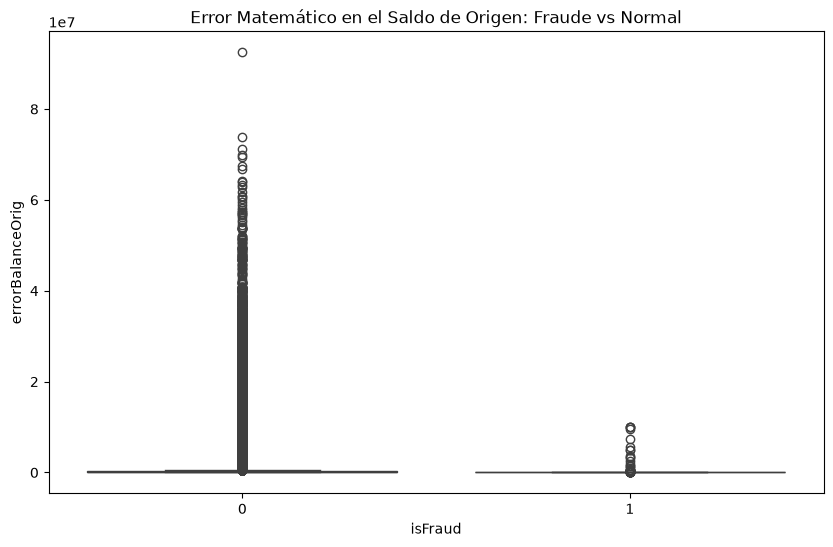

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_fraude_potencial, x='isFraud', y='errorBalanceOrig')
plt.title("Error Matemático en el Saldo de Origen: Fraude vs Normal")
plt.show()

Las transacciones que no son fraude muestran errores enormes (hasta ~9×10⁷), mientras que en los fraudes la caja se concentra en ~0, aunque hay una cola de fraudes con error positivo (hasta ~10⁷, típicamente con `oldbalanceOrg = 0`). Aun así, esto refleja cómo el simulador escribe los saldos, no una señal que un banco tendría antes de aprobar. Además, la escala extrema hace que el boxplot sea poco informativo; en una versión final conviene graficar `errorBalanceOrig != 0` como proporción por clase.

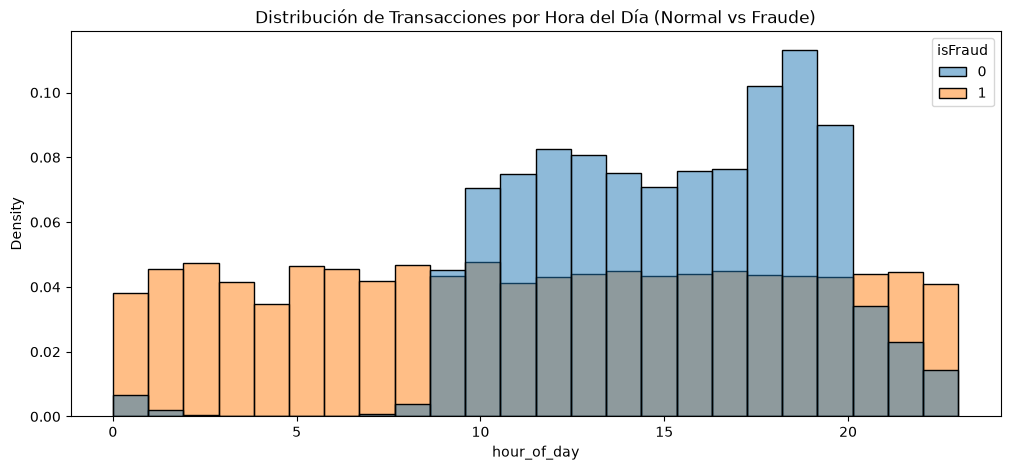

In [7]:
# Se extrae la Hora del Día (0 a 23)
df_fraude_potencial['hour_of_day'] = df_fraude_potencial['step'] % 24

# Se extrae el Día de la semana (asumiendo que step 1 es un inicio de semana, 0 a 6)
df_fraude_potencial['day_of_week'] = (df_fraude_potencial['step'] // 24) % 7

plt.figure(figsize=(12, 5))
sns.histplot(data=df_fraude_potencial, x='hour_of_day', hue='isFraud', stat='density', common_norm=False, bins=24)
plt.title("Distribución de Transacciones por Hora del Día (Normal vs Fraude)")
plt.show()

Las transacciones normales se concentran entre las 9 h y las 20 h; el fraude se reparte de forma casi uniforme las 24 horas, con mucho peso en la madrugada (0–8 h), donde casi no hay actividad legítima. Este patrón es plausible y aporta señal (en el modelo aparece como tercera variable por importancia).

Aún así no hay que perder de vista que PaySim es un dataset sintético y la hora no refleja el comportamiento de un sistema real. Es una señal para el ejercicio, no una conclusión de negocio. `day_of_week` se creó asumiendo que el `step` 1 es inicio de semana, supuesto que el dataset no confirma.

## 4. Banderas de negocio

Se crean dos banderas basadas en el saldo **antes** de la transacción (`oldbalanceOrg`) y el monto. Ambas se conocen al momento de decidir, así que son legítimas desde el punto de vista de disponibilidad.

In [8]:
# Cuenta de origen vacía intentando mover dinero
df_fraude_potencial['flag_empty_origin'] = ((df_fraude_potencial['oldbalanceOrg'] == 0) & 
                                            (df_fraude_potencial['amount'] > 0)).astype(int)

# El dinero que se mueve es EXACTAMENTE todo lo que hay en la cuenta (Vaciar la cuenta)
df_fraude_potencial['flag_empty_account'] = (df_fraude_potencial['amount'] == df_fraude_potencial['oldbalanceOrg']).astype(int)
df_fraude_potencial.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,hour_of_day,day_of_week,flag_empty_origin,flag_empty_account
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.0,0.00,1,0,0.00,1,0,0,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.0,0.00,1,0,0.00,1,0,0,1
15,1,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.0,51513.44,0,0,213808.94,1,0,0,0
19,1,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.0,0.00,0,0,214605.30,1,0,0,0
24,1,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.0,2719172.89,0,0,300850.89,1,0,0,0
42,1,CASH_OUT,110414.71,C768216420,26845.41,0.0,C1509514333,288800.0,2415.16,0,0,83569.30,1,0,0,0
47,1,CASH_OUT,56953.90,C1570470538,1942.02,0.0,C824009085,70253.0,64106.18,0,0,55011.88,1,0,0,0
48,1,CASH_OUT,5346.89,C512549200,0.00,0.0,C248609774,652637.0,6453430.91,0,0,5346.89,1,0,1,0
51,1,CASH_OUT,23261.30,C2072313080,20411.53,0.0,C2001112025,25742.0,0.00,0,0,2849.77,1,0,0,0
58,1,TRANSFER,62610.80,C1976401987,79114.00,16503.2,C1937962514,517.0,8383.29,0,0,0.00,1,0,0,0


In [9]:
# Contar cuántas veces aparece un nameDest en el dataset hasta ese 'step'
df_fraude_potencial = df_fraude_potencial.sort_values('step')

# Creamos una variable de la frecuencia de la cuenta destino
df_fraude_potencial['dest_transaction_count'] = df_fraude_potencial.groupby('nameDest').cumcount() + 1

In [12]:
# ¿Qué tan bien separa el fraude cada bandera?
for flag in ['flag_empty_origin', 'flag_empty_account']:
    tabla = (df_fraude_potencial.groupby(flag)['isFraud']
               .agg(transacciones='count', fraudes='sum', tasa_fraude='mean'))
    print(f"\n{flag}\n{tabla}")


flag_empty_origin
                   transacciones  fraudes  tasa_fraude
flag_empty_origin                                     
0                        1461843     8188     0.005601
1                        1308566       25     0.000019

flag_empty_account
                    transacciones  fraudes  tasa_fraude
flag_empty_account                                     
0                         2762375      179     0.000065
1                            8034     8034     1.000000


Dado que tasa_fraude para flag_empty_account=1 concentra casi todos los fraudes con una tasa de fraude muy superior al resto, por lo tanto esta bandera replica la regla del simulador.

## 5. Frecuencia de la cuenta destino

Se cuenta cuántas veces ha aparecido cada `nameDest` hasta ese momento. Una cuenta que recibe muchas transferencias seguidas es candidata a cuenta mula.

Esta variable **sí es legítima**: usa solo historial pasado (`cumcount` sobre datos ordenados por tiempo), información que un sistema en producción tendría.

In [ ]:
# Se ordenan temporalmente antes de agrupar para no usar información futura
df_fraude_potencial = df_fraude_potencial.sort_values('step', kind='stable')
df_fraude_potencial['dest_transaction_count'] = df_fraude_potencial.groupby('nameDest').cumcount() + 1

# 1 = primera vez que la cuenta recibe dinero; 2, 3, ... = recepciones sucesivas
df_fraude_potencial['dest_transaction_count'].describe()

count    2.770409e+06
mean     6.291217e+00
std      6.011013e+00
min      1.000000e+00
25%      2.000000e+00
50%      4.000000e+00
75%      9.000000e+00
max      7.500000e+01
Name: dest_transaction_count, dtype: float64

In [16]:
resumen = pd.DataFrame({
    'Origen vacío y destino ya visto':        [((df_fraude_potencial.dest_transaction_count>1) & (df_fraude_potencial.flag_empty_origin==1)).sum()],
    'Cuenta vaciada y destino nuevo':         [((df_fraude_potencial.dest_transaction_count==1) & (df_fraude_potencial.flag_empty_account==1)).sum()],
    'Fraudes con destino ya visto':           [((df_fraude_potencial.dest_transaction_count>1) & (df_fraude_potencial.isFraud==1)).sum()],
}).T.rename(columns={0:'filas'})
resumen

,filas
Origen vacío y destino ya visto,1245783
Cuenta vaciada y destino nuevo,5351
Fraudes con destino ya visto,2704


Los resultados de estas consultas fueron 1,245,783 filas (origen vacío y destino repetido), 5,351 (cuenta vaciada y destino nuevo) y 2,704 fraudes con destino ya visto. Es decir, cerca de un tercio de los fraudes llegan a cuentas que ya habían recibido dinero, útil a considerar al modelar.

In [17]:
df_fraude_potencial.groupby('nameDest')['dest_transaction_count'].count().sort_values(ascending=False).head(15)

nameDest
C1286084959    75
C665576141     68
C1360767589    68
C97730845      67
C248609774     64
C2006081398    63
C2083562754    63
C1590550415    62
C1789550256    62
C306206744     61
C985934102     61
C1023714065    61
C977993101     60
C1255024717    60
C991363637     59
Name: dest_transaction_count, dtype: int64

## 6. Variables para usarse en producción

Si el endpoint puede conocer la variable en el instante de decidir, entonces puede usarse en el modelo de producción

In [18]:
auditoria = pd.DataFrame([
    ('amount',                 'Pre-transacción',  'Sí',  'Dato de entrada de la operación'),
    ('oldbalanceOrg',          'Pre-transacción',  'Sí',  'Saldo del origen antes de operar'),
    ('oldbalanceDest',         'Pre-transacción',  'Sí',  'Saldo del destino antes de operar'),
    ('type_is_transfer',       'Pre-transacción',  'Sí',  'Tipo de operación'),
    ('hour_of_day',            'Pre-transacción',  'Sí',  'Derivada de la marca de tiempo'),
    ('day_of_week',            'Pre-transacción',  'Sí',  'Derivada de la marca de tiempo'),
    ('flag_empty_origin',      'Pre-transacción',  'Sí',  'Usa oldbalanceOrg y amount'),
    ('flag_empty_account',     'Pre-transacción',  'Sí*', 'Disponible, pero replica la regla del simulador'),
    ('dest_transaction_count', 'Historial',        'Sí',  'Solo usa transacciones pasadas'),
    ('newbalanceOrig',         'Post-transacción', 'NO',  'Fuga: resultado de ejecutar la operación'),
    ('newbalanceDest',         'Post-transacción', 'NO',  'Fuga: resultado de ejecutar la operación'),
    ('errorBalanceOrig',       'Post-transacción', 'NO',  'Fuga: se calcula con newbalanceOrig'),
], columns=['variable','momento','disponible_en_endpoint','comentario'])
auditoria

,variable,momento,disponible_en_endpoint,comentario
0,amount,Pre-transacción,Sí,Dato de entrada de la operación
1,oldbalanceOrg,Pre-transacción,Sí,Saldo del origen antes de operar
2,oldbalanceDest,Pre-transacción,Sí,Saldo del destino antes de operar
3,type_is_transfer,Pre-transacción,Sí,Tipo de operación
4,hour_of_day,Pre-transacción,Sí,Derivada de la marca de tiempo
5,day_of_week,Pre-transacción,Sí,Derivada de la marca de tiempo
6,flag_empty_origin,Pre-transacción,Sí,Usa oldbalanceOrg y amount
7,flag_empty_account,Pre-transacción,Sí*,"Disponible, pero replica la regla del simulador"
8,dest_transaction_count,Historial,Sí,Solo usa transacciones pasadas
9,newbalanceOrig,Post-transacción,NO,Fuga: resultado de ejecutar la operación


## Conclusiones del modelado

**Decisiones**

1. Filtrar a `TRANSFER` y `CASH_OUT` (todo el fraude está ahí).
2. **Se excluye** `newbalanceOrig`, `newbalanceDest` y `errorBalanceOrig` ya que ocasionan fuga de datos.
3. Entrenar versiones comparables: con y sin `flag_empty_account`, para cuantificar cuánto del rendimiento viene de la regla del simulador.
4. Elegir el umbral con la curva precision-recall en lugar de 0.5 para evitar desbalance entre el recall y la precisión.

**Limitaciones**

- PaySim es sintético: los patrones de hora, saldos y comportamiento del atacante son producto del simulador.
- Los resultados no deben leerse como rendimiento esperado en un entorno real.
- `isFlaggedFraud` se descartó: es una regla fija del simulador (solo marca transferencias > 200,000 en ciertos casos) con muy poca cobertura.